Давайте подивимося, як LSTM можна використовувати для побудови нейронної мережі прогнозування часових.

Будемо працювати з задачею прогнозування кількості пасажирів міжнародних авіаліній. З цим набором даних ми вже працювали в лекції "Time Series Analysis" і ви зможете порівняти результати :)

Задача полягає в тому, щоб за заданими роком і місяцем передбачити кількість пасажирів міжнародних авіаліній в одиницях виміру 1,000. Дані охоплюють період з січня 1949 року по грудень 1960 року, тобто 12 років, зі 144 спостереженнями.

Це регресійна задача. Тобто, знаючи кількість пасажирів (в тисячах) за останні місяці, можна передбачити, якою буде кількість пасажирів у наступному місяці. Набір даних має лише одну характеристику: "Кількість пасажирів" - `Passengers`.

Далі вже наведений код для читання даних, але нам їх ще треба буде трошки обробити.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader

In [2]:
# load data
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df.set_index('Month', inplace=True)
display(df.head())

,Passengers
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


**Завдання 1.** Створіть змінну типу `numpy.ndarray`, яка містить значення кількості пасажирів в форматі `float32`. Такий формат даних нам треба для тренування нейромережі.

In [3]:
num_pessengers = df['Passengers'].values.astype(np.float32)
num_pessengers[:5]

array([112., 118., 132., 129., 121.], dtype=float32)

Очікуваний результат:
```array([112., 118., 132., 129., 121.], dtype=float32)```

**Завдання 2**. Розбийте дані на тренувальні і валідаційні у співвідношенні 67% йде у тренування, 33 - у валідацію. Памʼятаємо, що ми працюємо з tim series, відповідно, навчаємось на давніших, валідуємось - на новіших.

In [4]:
n = len(num_pessengers)
print(f"num_pessengers size: {n}")

split_index = int(n * 0.67)
train, test = num_pessengers[:split_index], num_pessengers[split_index:]

print(f"train size: {len(train)}")
print(f"validation size: {len(test)}")

num_pessengers size: 144
train size: 96
validation size: 48


In [5]:
print("First 5 train elements:", train[:5])
print("First 5 test elements: ", test[:5])

First 5 train elements: [112. 118. 132. 129. 121.]
First 5 test elements:  [315. 301. 356. 348. 355.]


**Завдання 3**.

Реалізуйте функцію `create_dataset`, яка перетворить одномірний часовий ряд (набір даних) у формат, придатний для тренування нейромережі.

Функція повинна приймати два аргументи:
- `dataset` — numpy-масив часового ряду,
- `lookback` — кількість попередніх кроків, які використовуватимуться для передбачення.

Функція повинна повернути два **тензори** PyTorch:
- `X` — набір ознак (вікно попередніх значень),
- `y` — цільові значення (наступні після вікна кроки).

Дані ми будемо подавати моделі в наступному форматі:
`
tensor([[112.],
        [118.],
        [132.],
        [129.],
        [121.]])
`
Відповідно першою розмірністю буде йти розмір вхідного батча, а другою - розмір вхіднизх даних і в нас це 1, бо лише одне значення на вході щоразу.

Після виконання завдання запустіть код нижче. Ми будемо передбачати на основі кількості пасажирів в попередній день кількість пасажирів в наступний, тому `lookback == 1`.

In [6]:
def create_dataset(dataset: np.ndarray, lookback: int):
    X, y = [], []

    for i in range(len(dataset) - lookback):
        X.append(dataset[i: i + lookback])
        y.append(dataset[i+1: i+1+lookback])

    X = torch.tensor(np.array(X))
    y = torch.tensor(np.array(y))

    return X, y

In [7]:
lookback = 1
X_train, y_train = create_dataset(train, lookback=lookback)
X_test, y_test = create_dataset(test, lookback=lookback)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])


Очікуваний результат:
```
torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])
```

**Завдання 4**.

Зверніть увагу на розмірності в попередньому завданні. Ми
З допомогою модуля `torch.nn` опишіть клас `AirModel`, який є нейронною мережею для прогнозування кількості пасажирів за допомогою LSTM.

1. **Конструктор класу** повинен приймати параметри `hidden_size`, `num_layers` та ініціювати шари:
   - LSTM-шар з наступними параметрами:
     - `input_size` — кожна точка часового ряду є окремим входом,,
     - `hidden_size` — заданий в конструкторі класу мережі,
     - `num_layers=1` — кількість шарів LSTM, задана в конструкторі мережі,
     - `batch_first=True` — визначає, що першим виміром є розмір батчу.
   - Лінійний шар (`nn.Linear`) для перетворення виходу LSTM на прогноз однієї точки.

2. **Метод forward** повинен виконувати наступні дії:
   - Передати вхідний тензор через LSTM-шар і отримати виходи (ігноруючи приховані стани).
   - Пропустити вихід LSTM через лінійний шар для отримання остаточного прогнозу.

Створіть об'єкт класу `AirModel` зі значеннями параметрів `hidden_size=50`, `num_layers=1` і протестуйте роботу моделі на вхідному тензорі `tensor([[112.]])`. На цьому етапі ми маємо переконатись, що модель здатна генерувати передбачення з рандомно ініційованими вагами.

In [8]:
class AirModel(nn.Module):
    def __init__(self, hidden_size, num_layers):
        super(AirModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=lookback,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, out_features=1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out)
        return out

In [9]:
hidden_size = 50
num_layers = 1

model = AirModel(hidden_size, num_layers)
model

AirModel(
  (lstm): LSTM(1, 50, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)

In [10]:
model(torch.tensor([[112.]]))

tensor([[-0.1549]], grad_fn=<AddmmBackward0>)

**Завдання 5**.

Створіть об'єкт DataLoader для завантаження даних, використовуючи тренувальні вибірки `X_train` та `y_train`. Ваш DataLoader повинен виконувати наступні вимоги:

1. Використовувати клас `TensorDataset`, щоб об'єднати тензори ознак `X_train` і цільових значень `y_train`.
2. Дані повинні завантажуватися невеликими батчами розміром 8 за допомогою параметра `batch_size`.
3. Використовувати параметр `shuffle=True`, щоб дані перемішувалися перед кожною епохою тренування.


In [12]:
batch_size = 8
train_ds = TensorDataset(X_train, y_train)
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

**Завдання 6**.

1. Реалізуйте навчання нейронної мережі `AirModel` для прогнозування часових рядів, використовуючи Adam-оптимізатор та функцію втрат MSE (середньоквадратичну похибку).
2. Створіть цикл тренування для 2000 епох, у якому на кожній епосі:
   - Виконуйте крок тренування моделі (прямий прохід, обчислення похибки, зворотний прохід і оновлення ваг).
   - Підраховуйте середню похибку на кожному батчі даних і зберігайте її у списку `losses`.
3. Раз на 100 епох проводьте валідацію моделі:
   - Перевіряйте модель на тренувальних та тестових даних без оновлення ваг.
   - Обчислюйте корінь середньоквадратичної похибки (RMSE) для тренувальної та тестової вибірок і виводьте результати на екран.
   
**Примітка:**
- Використовуйте вже створений `DataLoader` для отримання батчів даних.
- Валідацію виконуйте в режимі `eval()`, вимикаючи обчислення градієнтів з `torch.no_grad()`.

**Приклад виходу:**
```
Epoch 0: train RMSE 12.3456, test RMSE 15.6789
Epoch 100: train RMSE 9.8765, test RMSE 12.3456
...
```

In [13]:
n_epochs = 2000
validate_every = 100
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = F.mse_loss

In [14]:
def train_eval(num_epochs, model, dataloader, loss_fn, optimizer):
    all_losses = []
    for epoch in range(num_epochs + 1):
        epoch_loss = 0
        model.train()

        for X, y in dataloader:
            optimizer.zero_grad()

            # Compute the prediction error
            pred = model(X)
            loss = loss_fn(pred, y)

            # Backpropagation
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        # Calculate loss
        avg_loss = epoch_loss / len(dataloader)
        all_losses.append(avg_loss)

        if (epoch) % validate_every == 0:
            model.eval()

            with torch.no_grad():
                train_pred = model(X_train)
                train_rmse = torch.sqrt(loss_fn(train_pred, y_train))

                test_pred = model(X_test)
                test_rmse = torch.sqrt(loss_fn(test_pred, y_test))
            print(f"Epoch {epoch}: train RMSE {train_rmse:.4f}, test RMSE {test_rmse:.4f}")

    return all_losses

In [15]:
all_losses = train_eval(n_epochs, model, train_dl, loss_fn, optimizer)

Epoch 0: train RMSE 226.1785, test RMSE 422.5925
Epoch 100: train RMSE 178.0717, test RMSE 372.2662
Epoch 200: train RMSE 139.6732, test RMSE 330.4257
Epoch 300: train RMSE 108.7142, test RMSE 293.8160
Epoch 400: train RMSE 86.2939, test RMSE 262.1339
Epoch 500: train RMSE 68.1158, test RMSE 235.0116
Epoch 600: train RMSE 49.7188, test RMSE 201.4573
Epoch 700: train RMSE 38.9430, test RMSE 176.2240
Epoch 800: train RMSE 32.5093, test RMSE 155.7358
Epoch 900: train RMSE 29.7155, test RMSE 138.8033
Epoch 1000: train RMSE 25.7598, test RMSE 124.0014
Epoch 1100: train RMSE 25.5248, test RMSE 114.9519
Epoch 1200: train RMSE 24.2695, test RMSE 104.8649
Epoch 1300: train RMSE 23.8082, test RMSE 100.7892
Epoch 1400: train RMSE 23.2509, test RMSE 94.8409
Epoch 1500: train RMSE 23.3622, test RMSE 92.4791
Epoch 1600: train RMSE 23.0125, test RMSE 85.8132
Epoch 1700: train RMSE 23.2810, test RMSE 93.6734
Epoch 1800: train RMSE 23.1103, test RMSE 91.0633
Epoch 1900: train RMSE 23.3637, test RMSE 85

**Завдання 7.** Побудуйте графік лосів. Зробіть висновок з графіку, чи навчилась модель?

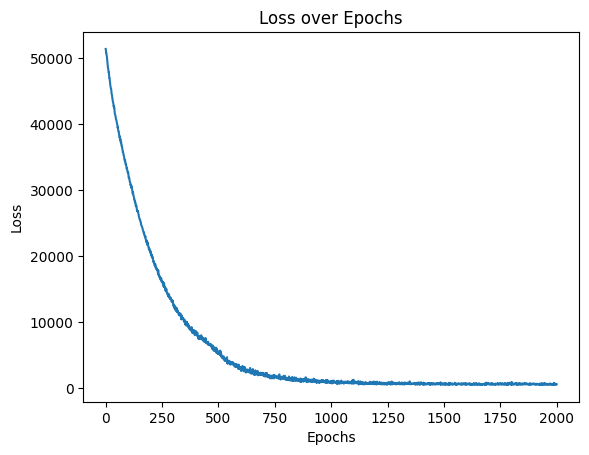

In [16]:
plt.plot(all_losses)
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show();

Модель навчилась, але не факт, що точно)

Щоб краще зрозуміти якість прогнозу, ви можете побудувати графік з кодом нижче (а ще нижче - описано, що відбувається в цьому коді, бо це теж корисно зрозуміти):

/tmp/ipython-input-2935284368.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  train_plot[lookback:train_size] = model(X_train)[:, -1]
/tmp/ipython-input-2935284368.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  test_plot[train_size+lookback:len(num_pessengers)] = model(X_test)[:, -1]


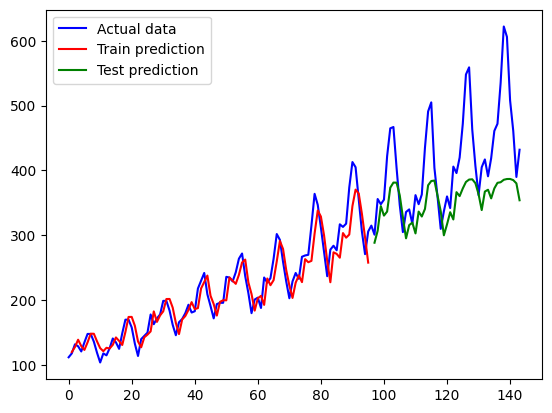

In [17]:
def plot_predicts():
  with torch.no_grad():
      train_size = len(train)
      train_plot = np.ones_like(num_pessengers) * np.nan
      train_plot[lookback:train_size] = model(X_train)[:, -1]

      test_plot = np.ones_like(num_pessengers) * np.nan
      test_plot[train_size+lookback:len(num_pessengers)] = model(X_test)[:, -1]

      plt.plot(num_pessengers, 'b', label='Actual data')
      plt.plot(train_plot, 'r', label='Train prediction')
      plt.plot(test_plot, 'g', label='Test prediction')
      plt.legend()
      plt.show();

plot_predicts()

The model performs well on train data but worst on test data.

**Що відбувається в коді вище.** В цьому коді здійснюється процес прогнозування часових рядів за допомогою LSTM моделі, а також виведення графіку, який показує реальні значення, тренувальні та тестові прогнози. Ось що відбувається на кожному етапі:

1. **`torch.no_grad()`**: Цей контекстний менеджер вимикає обчислення градієнтів, що означає, що під час прогнозування не будуть зберігатися проміжні обчислення для зворотного проходу (backpropagation). Це підвищує ефективність під час прогнозування і зменшує використання пам'яті.

2. **Зсув прогнозів для тренувальних даних:**
   - Створюється масив `train_plot`, який має такий самий розмір, як і часовий ряд (`timeseries`), і заповнюється значеннями NaN (`np.nan`), щоб залишити місце для реальних значень.
   - Модель передбачає виходи для тренувальних даних `X_train`.
   - Використовується лише останнє передбачене значення для кожного входу LSTM (`y_pred[:, -1]`).
   - Прогнози зсуваються, починаючи з індексу `lookback` до кінця тренувальних даних (індекс `train_size`). Цей зсув потрібен, щоб зробити прогноз на основі попередніх даних і відобразити його на правильній частині графіку.

3. **Зсув прогнозів для тестових даних:**
   - Створюється масив `test_plot`, який також заповнюється NaN.
   - Прогнози для тестових даних додаються з індексу `train_size + lookback` до кінця реальних даних, щоб відобразити, де модель починає прогнозувати тестову вибірку.

4. **Побудова графіка:**
   - `plt.plot(timeseries, c='b')`: Виводить реальні значення часового ряду (синя лінія).
   - `plt.plot(train_plot, c='r')`: Виводить тренувальні прогнози (червона лінія).
   - `plt.plot(test_plot, c='g')`: Виводить тестові прогнози (зелена лінія).

**Чому це робиться:**
- Зсув прогнозів для тренувальних і тестових даних дозволяє візуально зрівняти, наскільки добре модель прогнозує як на тренувальній, так і на тестовій вибірках. Зазвичай, червона лінія (тренувальні прогнози) повинна точно відповідати синій лінії (реальні дані), а зелена лінія (тестові прогнози) дає змогу побачити, наскільки модель добре працює на нових даних, яких вона раніше не бачила.

**Завдання 8**. Навчіть модель з hidden_size=100 та порівняйте результати прогнозів з попередніми.

In [18]:
hidden_size = 100
num_layers = 1
model_100 = AirModel(hidden_size, num_layers)

n_epochs = 2000
optimizer = torch.optim.Adam(model_100.parameters(), lr=0.001)
loss_fn = F.mse_loss

In [19]:
all_losses = train_eval(n_epochs, model_100, train_dl, loss_fn, optimizer)

Epoch 0: train RMSE 225.5054, test RMSE 422.1143
Epoch 100: train RMSE 128.4171, test RMSE 317.5829
Epoch 200: train RMSE 81.1022, test RMSE 252.9173
Epoch 300: train RMSE 51.8231, test RMSE 205.5445
Epoch 400: train RMSE 35.9075, test RMSE 166.3916
Epoch 500: train RMSE 28.7857, test RMSE 141.6767
Epoch 600: train RMSE 25.1108, test RMSE 120.1972
Epoch 700: train RMSE 23.9525, test RMSE 106.9196
Epoch 800: train RMSE 24.1357, test RMSE 94.8716
Epoch 900: train RMSE 23.0064, test RMSE 88.8498
Epoch 1000: train RMSE 23.0782, test RMSE 83.4032
Epoch 1100: train RMSE 22.9668, test RMSE 84.2279
Epoch 1200: train RMSE 22.7264, test RMSE 79.8703
Epoch 1300: train RMSE 23.5880, test RMSE 80.1313
Epoch 1400: train RMSE 22.4977, test RMSE 79.3110
Epoch 1500: train RMSE 22.8057, test RMSE 78.5083
Epoch 1600: train RMSE 22.5198, test RMSE 72.0788
Epoch 1700: train RMSE 23.2361, test RMSE 72.5108
Epoch 1800: train RMSE 22.1137, test RMSE 71.1542
Epoch 1900: train RMSE 22.7635, test RMSE 72.0558
Ep

The model with `hidden_size=100` performs better: test RMSE `78.5021` compared to test RMSE `85.2334`

/tmp/ipython-input-3069225406.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  train_plot[lookback:train_size] = model(X_train)[:, -1]
/tmp/ipython-input-3069225406.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  test_plot[train_size+lookback:len(num_pessengers)] = model(X_test)[:, -1]
/tmp/ipython-input-3069225406.py:13: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  train_100_plot[lookback:train_size] = model_100(X_train)[:, -1]
/tmp/ipython-input-3069225406.py:16: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'co

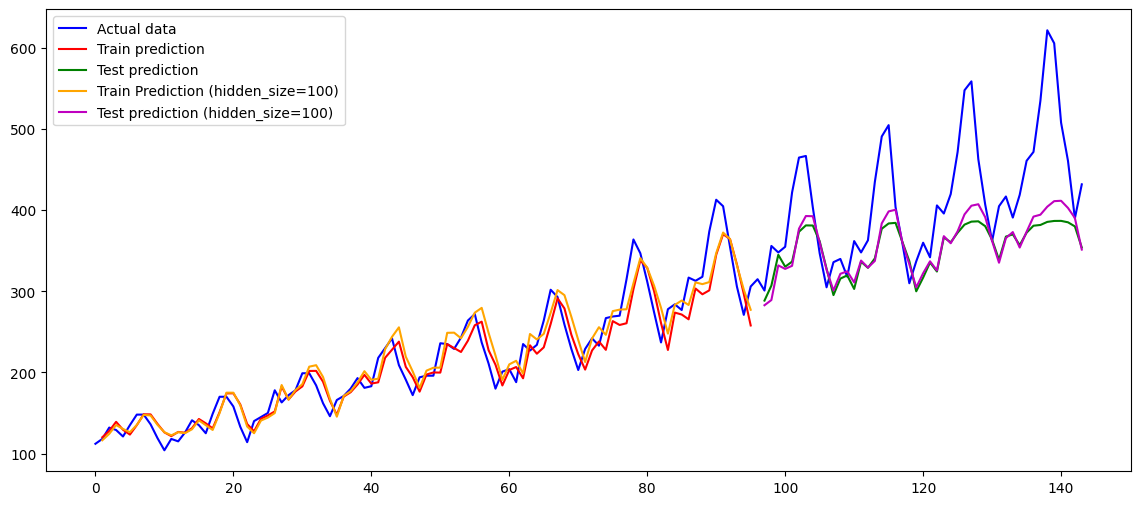

In [20]:
def plot_predicts():
  with torch.no_grad():
      plt.figure(figsize=(14, 6))
      train_size = len(train)

      train_plot = np.ones_like(num_pessengers) * np.nan
      train_plot[lookback:train_size] = model(X_train)[:, -1]

      test_plot = np.ones_like(num_pessengers) * np.nan
      test_plot[train_size+lookback:len(num_pessengers)] = model(X_test)[:, -1]

      train_100_plot = np.ones_like(num_pessengers) * np.nan
      train_100_plot[lookback:train_size] = model_100(X_train)[:, -1]

      test_100_plot = np.ones_like(num_pessengers) * np.nan
      test_100_plot[train_size+lookback:len(num_pessengers)] = model_100(X_test)[:, -1]

      plt.plot(num_pessengers, 'b', label='Actual data')
      plt.plot(train_plot, 'r', label='Train prediction')
      plt.plot(test_plot, 'g', label='Test prediction')
      plt.plot(train_100_plot, 'orange', label='Train Prediction (hidden_size=100)')
      plt.plot(test_100_plot, 'm', label='Test prediction (hidden_size=100)')
      plt.legend()
      plt.show();

plot_predicts()

The plot shows the difference between predictions from 2 models, and we can see that the model with `hidden_size=100` performs better.